<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_13_Matplotlib Format Charts.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 🟩 Subplots with Bar Charts (2.13.1)

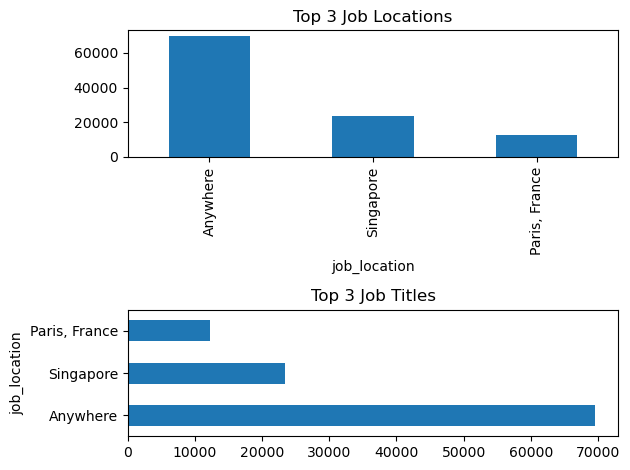

In [2]:
fig, ax = plt.subplots(2,1)

top3_locations = df['job_location'].value_counts()[:3]
top3_locations.plot(kind='bar', ax=ax[0], title='Top 3 Job Locations')
top3_titles = df['job_location'].value_counts()[:3]
top3_titles.plot(kind='barh', ax=ax[1], title='Top 3 Job Titles')

fig.tight_layout()
plt.show()

---

## 🟨 Subplots with Job Titles by Schedule (2.13.2)

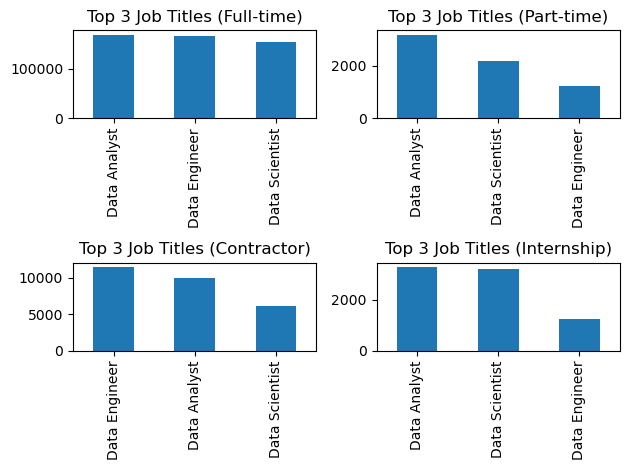

In [3]:
# Code Needed
schedules = ['Full-time', 'Part-time', 'Contractor', 'Internship']
fig, ax = plt.subplots(2,2)

ax = ax.flatten()
for i, schedule in enumerate(schedules):
    # print(df[df['job_schedule_type'] == schedule].head())
    scheduled_plot = df[df['job_schedule_type'] == schedule]['job_title_short'].value_counts().head(3)
    scheduled_plot.plot(kind='bar', ax=ax[i], title=f'Top 3 Job Titles ({schedule})', xlabel='')
fig.tight_layout()
plt.show()

---

## 🟥 Top Skills for Job Roles Subplots (2.13.3)

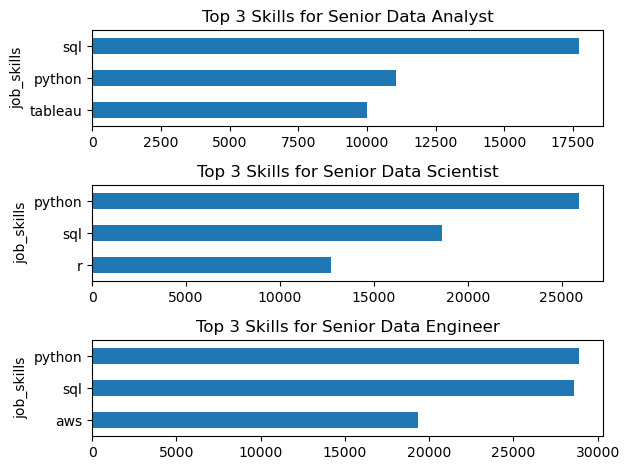

In [4]:
# Code Needed
job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']
fig, ax = plt.subplots(3,1)
df_skills_exploded = df.explode('job_skills')

for i, role in enumerate(job_roles):
    df_role = df_skills_exploded[df_skills_exploded['job_title_short'] == role]
    top_3 = df_role['job_skills'].value_counts()[:3]
    top_3.plot(kind='barh', ax=ax[i], title = f'Top 3 Skills for {role}')
    ax[i].invert_yaxis()
fig.tight_layout()
plt.show()

---